In [2]:
import pandas as pd
import numpy as np
from tslearn.datasets import UCR_UEA_datasets
import matplotlib.pyplot as plt
import seaborn as sns

# Data

In [3]:
ds = UCR_UEA_datasets()
X_train, y_train, X_test, y_test = ds.load_dataset("LSST")

# RF & simple features

              precision    recall  f1-score   support

          15       0.70      0.48      0.57       124
          16       0.90      0.90      0.90       270
          42       0.53      0.37      0.43       382
          52       1.00      0.02      0.03        63
          53       0.75      0.86      0.80         7
           6       0.38      0.26      0.31        35
          62       0.42      0.24      0.30       153
          64       0.00      0.00      0.00        24
          65       0.70      0.66      0.68       313
          67       0.89      0.12      0.21        68
          88       0.88      0.75      0.81       121
          90       0.59      0.93      0.72       777
          92       0.85      0.90      0.87        77
          95       0.41      0.13      0.20        52

    accuracy                           0.65      2466
   macro avg       0.64      0.47      0.49      2466
weighted avg       0.65      0.65      0.61      2466



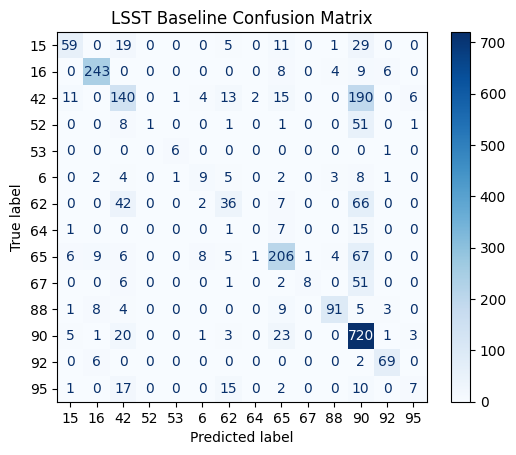

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

def get_features(X):
    """
    Extracts physical summary statistics for each of the 6 filters.
    Flattening raw 36 steps is often too noisy for LSST.
    """
    # Features: Mean, Std, Max, Min, and Amplitude for each of the 6 channels
    stats = [
        np.mean(X, axis=1), 
        np.std(X, axis=1), 
        np.max(X, axis=1), 
        np.min(X, axis=1),
        np.ptp(X, axis=1) # Peak-to-peak amplitude
    ]
    return np.hstack(stats)

# Processing
X_train_feats = get_features(X_train)
X_test_feats = get_features(X_test)

# Model - Random Forest is robust to the non-linear nature of light curves
rf = RandomForestClassifier(n_estimators=500, class_weight="balanced", random_state=42, n_jobs=-1)
rf.fit(X_train_feats, y_train)

# Evaluation
y_pred = rf.predict(X_test_feats)
print(classification_report(y_test, y_pred))

# Visualizing Confusion Matrix
ConfusionMatrixDisplay.from_estimator(rf, X_test_feats, y_test, cmap='Blues')
plt.title("LSST Baseline Confusion Matrix")
plt.show()

# RF & advanced features

In [4]:
from scipy.stats import skew, kurtosis

def get_extensive_features(X):
    """
    Extensive feature extraction for LSST time series (N, 36, 6).
    Includes temporal indices (argmax/argmin) and morphological stats.
    """
    # 1. Basic moments & Distribution
    mu = np.mean(X, axis=1)
    sigma = np.std(X, axis=1)
    sk = skew(X, axis=1)
    ku = kurtosis(X, axis=1)
    
    # 2. Extreme values & Range
    minimum = np.min(X, axis=1)
    maximum = np.max(X, axis=1)
    median = np.median(X, axis=1)
    range_val = maximum - minimum
    
    # 3. Temporal Indices (Crucial for light curve phase)
    # Normalized by the sequence length (36) to stay in [0, 1] range
    idx_max = np.argmax(X, axis=1) / 36.0
    idx_min = np.argmin(X, axis=1) / 36.0
    # Time distance between min and max
    time_diff_peaks = (np.argmax(X, axis=1) - np.argmin(X, axis=1)) / 36.0
    
    # 4. Dynamics & Gradients
    diffs = np.diff(X, axis=1)
    mean_diff = np.mean(diffs, axis=1)
    std_diff = np.std(diffs, axis=1)
    # "Slope to peak" - proxy for rise time
    # (max_val - start_val) / (time_of_max + 1)
    rise_slope = (maximum - X[:, 0, :]) / (np.argmax(X, axis=1) + 1e-5)
    
    # 5. Energy
    energy = np.sum(X**2, axis=1)

    features = [
        mu, sigma, sk, ku, 
        minimum, maximum, median, range_val,
        idx_max, idx_min, time_diff_peaks,
        mean_diff, std_diff, rise_slope,
        energy
    ]
    
    return np.hstack(features)

# Processing
X_train_ext = get_extensive_features(X_train)
X_test_ext = get_extensive_features(X_test)

/opt/python/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/python/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/python/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

          15       0.70      0.48      0.57       124
          16       0.95      0.96      0.96       270
          42       0.60      0.39      0.47       382
          52       0.00      0.00      0.00        63
          53       0.75      0.86      0.80         7
           6       0.56      0.29      0.38        35
          62       0.44      0.13      0.20       153
          64       0.00      0.00      0.00        24
          65       0.75      0.67      0.71       313
          67       0.67      0.09      0.16        68
          88       0.96      0.84      0.90       121
          90       0.56      0.95      0.71       777
          92       0.88      0.91      0.89        77
          95       0.83      0.10      0.17        52

    accuracy                           0.66      2466
   macro avg       0.62      0.48      0.49      2466
weighted avg       0.65      0.66      0.62      2466



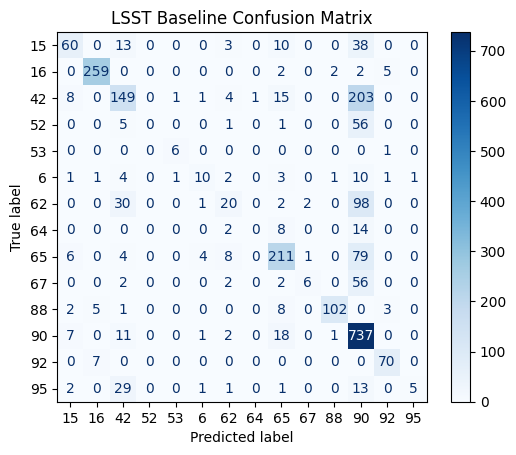

In [5]:
# Model - Random Forest is robust to the non-linear nature of light curves
rf = RandomForestClassifier(n_estimators=500, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train_ext, y_train)

# Evaluation
y_pred = rf.predict(X_test_ext)
print(classification_report(y_test, y_pred))

# Visualizing Confusion Matrix
ConfusionMatrixDisplay.from_estimator(rf, X_test_ext, y_test, cmap='Blues')
plt.title("LSST Baseline Confusion Matrix")
plt.show()

# Baseline deep

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LSSTNet(nn.Module):
    def __init__(self, n_classes):
        super(LSSTNet, self).__init__()
        # Input shape: (Batch, 6, 36) -> Conv1D expects (Channels, Length)
        self.conv1 = nn.Conv1d(6, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool1d(2)
        
        # After two pools: 36 -> 18 -> 9
        self.fc1 = nn.Linear(64 * 9, 128)
        self.fc2 = nn.Linear(128, n_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        # Ensure shape is (Batch, Features, Time)
        x = x.transpose(1, 2) 
        
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        
        x = x.view(x.size(0), -1) # Flatten
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

# Initialization
n_categories = len(np.unique(y_train))
model = LSSTNet(n_classes=n_categories)

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

# 1. Preprocessing & Encoding
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

n_classes = len(le.classes_)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Model Architecture
class LSSTNet(nn.Module):
    def __init__(self, n_classes):
        super(LSSTNet, self).__init__()
        # Input: (Batch, 36, 6) -> We transpose to (Batch, 6, 36)
        self.conv1 = nn.Conv1d(6, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool1d(2)
        self.dropout = nn.Dropout(0.1)
        # 36 -> pool -> 18 -> pool -> 9
        self.fc1 = nn.Linear(128 * 9, 128)
        self.fc2 = nn.Linear(128, n_classes)

    def forward(self, x):
        x = x.transpose(1, 2) # To (Batch, Channels, Length)
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x)

# 3. Data Loaders
def get_loaders(X_tr, y_tr, X_te, y_te, batch_size=64):
    train_ds = TensorDataset(torch.FloatTensor(X_tr), torch.LongTensor(y_tr))
    test_ds = TensorDataset(torch.FloatTensor(X_te), torch.LongTensor(y_te))
    return (DataLoader(train_ds, batch_size=batch_size, shuffle=True),
            DataLoader(test_ds, batch_size=batch_size))

train_loader, test_loader = get_loaders(X_train, y_train_enc, X_test, y_test_enc)

# 4. Training Setup
model = LSSTNet(n_classes).to(device)
weights = compute_class_weight('balanced', classes=np.unique(y_train_enc), y=y_train_enc)
criterion = nn.CrossEntropyLoss(weight=torch.FloatTensor(weights).to(device))
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)

# 5. Execution Loop
def run_train(epochs=100):
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            loss = criterion(model(data), target)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1} | Loss: {total_loss/len(train_loader):.4f}")

run_train(500)

# 6. Evaluation
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for data, target in test_loader:
        output = model(data.to(device))
        y_pred.extend(torch.argmax(output, dim=1).cpu().numpy())
        y_true.extend(target.numpy())

print("\nReport:")
print(classification_report(y_true, y_pred, target_names=le.classes_))

Epoch 20 | Loss: 2.2280
Epoch 40 | Loss: 2.0483
Epoch 60 | Loss: 1.3254
Epoch 80 | Loss: 1.1243
Epoch 100 | Loss: 1.1786
Epoch 120 | Loss: 1.1881
Epoch 140 | Loss: 0.8878
Epoch 160 | Loss: 0.8276
Epoch 180 | Loss: 0.7530
Epoch 200 | Loss: 0.6622
Epoch 220 | Loss: 0.5201
Epoch 240 | Loss: 0.4670
Epoch 260 | Loss: 0.3644
Epoch 280 | Loss: 0.3333
Epoch 300 | Loss: 0.3706
Epoch 320 | Loss: 0.4666
Epoch 340 | Loss: 0.3340
Epoch 360 | Loss: 0.2508
Epoch 380 | Loss: 0.2155
Epoch 400 | Loss: 0.2150
Epoch 420 | Loss: 0.1611
Epoch 440 | Loss: 0.1898
Epoch 460 | Loss: 0.2938
Epoch 480 | Loss: 0.1056
Epoch 500 | Loss: 0.1298

Report:
              precision    recall  f1-score   support

          15       0.57      0.60      0.58       124
          16       0.84      0.83      0.84       270
          42       0.43      0.46      0.44       382
          52       0.14      0.16      0.15        63
          53       1.00      0.57      0.73         7
           6       0.35      0.17      0.23  